# **Code**

In [1]:
#Simulating a randomly rolled die
import numpy as np
die_roll = np.random.randint(1, 7)
assert 1 <= die_roll <= 6

In [2]:
#Seeding reproducible random die rolls
np.random.seed(0)
die_rolls = [np.random.randint(1, 7) for _ in range(3)]
assert die_rolls == [5, 6, 1]

In [3]:
#Simulating one fair coin flip
np.random.seed(0)
coin_flip = np.random.randint(0, 2)
print(f"Coin landed on {'heads' if coin_flip == 1 else 'tails'}")

Coin landed on tails


In [4]:
#Simulating 10 fair coin flips
np.random.seed(0)
def frequency_heads(coin_flip_sequence):
 total_heads = len([head for head in coin_flip_sequence if head == 1])
 return total_heads / len(coin_flip_sequence)
coin_flips = [np.random.randint(0, 2) for _ in range(10)]
freq_heads = frequency_heads(coin_flips)
print(f"Frequency of Heads is {freq_heads}")

Frequency of Heads is 0.8


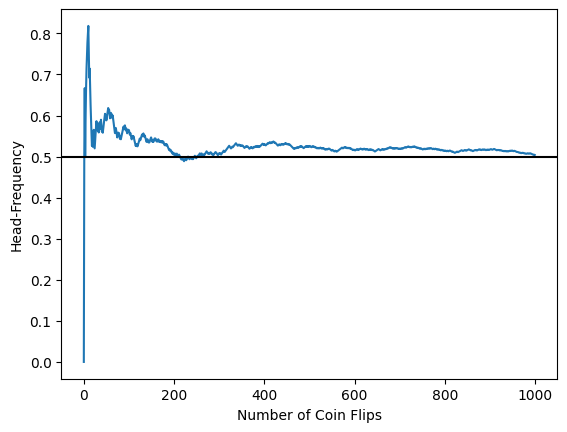

In [9]:
#Plotting simulated fair coin-flip frequencies
import matplotlib.pyplot as plt
np.random.seed(0)
coin_flips = []
frequencies = []
for _ in range(1000):
 coin_flips.append(np.random.randint(0, 2))
 frequencies.append(frequency_heads(coin_flips))
plt.plot(list(range(1000)), frequencies)
plt.axhline(0.5, color='k')
plt.xlabel('Number of Coin Flips')
plt.ylabel('Head-Frequency')
plt.show()

In [10]:
#Simulating biased coin flips
np.random.seed(0)
print("Let's flip the biased coin once.")
coin_flip = np.random.binomial(1, 0.7)
print(f"Biased coin landed on {'heads' if coin_flip == 1 else 'tails'}.")
print("\nLet's flip the biased coin 10 times.")
number_coin_flips = 10
head_count = np.random.binomial(number_coin_flips, .7)
print((f"{head_count} heads were observed out of "
 f"{number_coin_flips} biased coin flips"))

Let's flip the biased coin once.
Biased coin landed on heads.

Let's flip the biased coin 10 times.
6 heads were observed out of 10 biased coin flips


In [11]:
#Computing coin-flip-frequency convergence
np.random.seed(0)
head_count = np.random.binomial(1000, 0.7)
frequency = head_count / 1000
print(f"Frequency of Heads is {frequency}")

Frequency of Heads is 0.697


In [14]:
#Recomputing coin-flip-frequency convergence
np.random.seed(0)
assert np.random.binomial(1000, 0.7) / 1000 == 0.697
for i in range(1, 6):
 head_count = np.random.binomial(1000, 0.7)
 frequency = head_count / 1000
 print(f"Frequency at iteration {i} is {frequency}")
 if frequency == 0.7:
  print("Frequency equals the probability!\n")

Frequency at iteration 1 is 0.69
Frequency at iteration 2 is 0.7
Frequency equals the probability!

Frequency at iteration 3 is 0.707
Frequency at iteration 4 is 0.702
Frequency at iteration 5 is 0.699


In [15]:
#Computing frequencies with 500 flips per sample
np.random.seed(0)
head_count_list = [np.random.binomial(1000, 0.7) for _ in range(500)]

In [16]:
#Optimizing the coin-flip-frequency computation
np.random.seed(0)
head_count_array = np.random.binomial(1000, 0.7, 500)

In [17]:
#Converting a NumPy array to a Python list
assert head_count_array.tolist() == head_count_list

In [18]:
#Converting a Python list to a NumPy array
new_array = np.array(head_count_list)
assert np.array_equal(new_array, head_count_array) == True

In [20]:
#Computing frequencies using NumPy
frequency_array = head_count_array / 1000
assert frequency_array.tolist() == [head_count / 1000
 for head_count in head_count_list]
assert frequency_array.tolist() == list(map(lambda x: x / 1000,
 head_count_list))

In [21]:
#Printing a NumPy frequency array
print(frequency_array[:20])

[0.697 0.69  0.7   0.707 0.702 0.699 0.723 0.67  0.702 0.713 0.721 0.689
 0.711 0.697 0.717 0.691 0.731 0.697 0.722 0.728]


In [22]:
#Finding the largest and smallest frequency values
min_freq = frequency_array.min()
max_freq = frequency_array.max()
print(f"Minimum frequency observed: {min_freq}")
print(f"Maximum frequency observed: {max_freq}")
print(f"Difference across frequency range: {max_freq - min_freq}")

Minimum frequency observed: 0.656
Maximum frequency observed: 0.733
Difference across frequency range: 0.07699999999999996


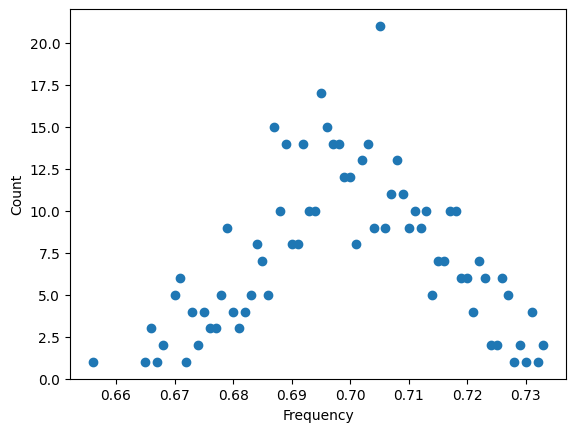

In [24]:
#Plotting measured frequencies
from collections import defaultdict
frequency_counts = defaultdict(int)
for frequency in frequency_array:
 frequency_counts[frequency] += 1
frequencies = list(frequency_counts.keys())
counts = [frequency_counts[freq] for freq in frequencies]
plt.scatter(frequencies, counts)
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.show()

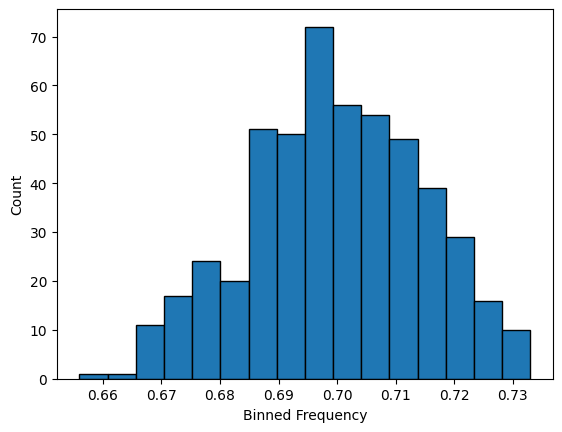

In [25]:
#Plotting a frequency histogram using plt.hist
plt.hist(frequency_array, bins='auto', edgecolor='black')
plt.xlabel('Binned Frequency')
plt.ylabel('Count')
plt.show()

Number of Bins: 16


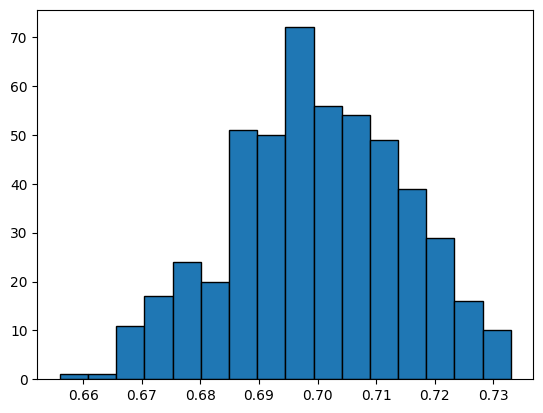

In [26]:
#Counting bins in a plotted histogram
counts, _, _ = plt.hist(frequency_array, bins='auto',
 edgecolor='black')
print(f"Number of Bins: {counts.size}")

Bin width: 0.004812499999999997


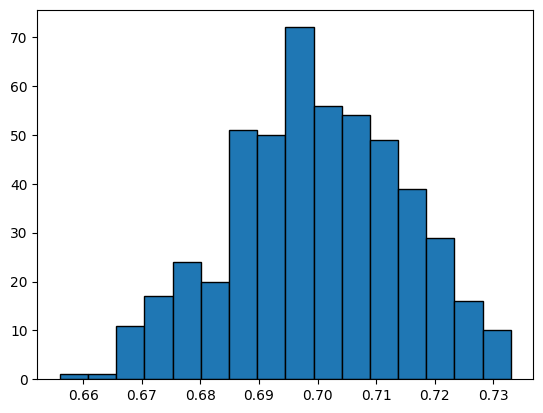

In [27]:
#Finding the width of bins in a histogram
counts, bin_edges, _ = plt.hist(frequency_array, bins='auto',
 edgecolor='black')
bin_width = bin_edges[1] - bin_edges[0]
assert bin_width == (max_freq - min_freq) / counts.size
print(f"Bin width: {bin_width}")

In [28]:
#Getting a bin’s frequency and size
def output_bin_coverage(i):
 count = int(counts[i])
 range_start, range_end = bin_edges[i], bin_edges[i+1]
 range_string = f"{range_start} - {range_end}"
 print((f"The bin for frequency range {range_string} contains "
 f"{count} element{'' if count == 1 else 's'}"))
output_bin_coverage(0)
output_bin_coverage(5)

The bin for frequency range 0.656 - 0.6608125 contains 1 element
The bin for frequency range 0.6800625 - 0.684875 contains 20 elements


In [29]:
#Finding the index of an array’s maximum value
assert counts[counts.argmax()] == counts.max()

In [30]:
#Using argmax to return a histogram’s peak
output_bin_coverage(counts.argmax())

The bin for frequency range 0.6945 - 0.6993125 contains 72 elements


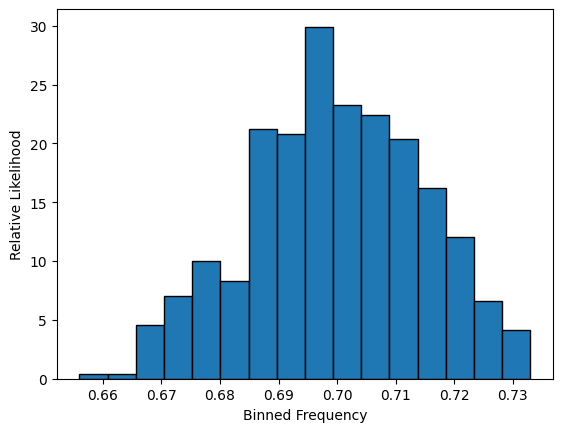

In [31]:
#Plotting a histogram’s relative likelihoods
likelihoods, bin_edges, _ = plt.hist(frequency_array, bins='auto',
 edgecolor='black', density=True)
plt.xlabel('Binned Frequency')
plt.ylabel('Relative Likelihood')
plt.show()

In [32]:
#Computing the total area under a histogram
assert likelihoods.sum() * bin_width == 1.0

In [33]:
#Computing the probability of the peak frequencies
index = likelihoods.argmax()
area = likelihoods[index] * bin_width
range_start, range_end = bin_edges[index], bin_edges[index+1]
range_string = f"{range_start} - {range_end}"
print(f"Sampled frequency falls within interval {range_string} with probability {area}")

Sampled frequency falls within interval 0.6945 - 0.6993125 with probability 0.144


In [34]:
#Increasing the probability of a frequency range
peak_index = likelihoods.argmax()
start_index, end_index = (peak_index - 1, peak_index + 2)
area = likelihoods[start_index: end_index + 1].sum() * bin_width
range_start, range_end = bin_edges[start_index], bin_edges[end_index]
range_string = f"{range_start} - {range_end}"
print(f"Sampled frequency falls within interval {range_string} with probability {area}")

Sampled frequency falls within interval 0.6896875 - 0.704125 with probability 0.464


In [37]:
#Computing a high confidence interval
def compute_high_confidence_interval(likelihoods, bin_width):
 peak_index = likelihoods.argmax()
 area = likelihoods[peak_index] * bin_width
 start_index, end_index = peak_index, peak_index + 1
 while area < 0.95:
  if start_index > 0:
    start_index -= 1
  if end_index < likelihoods.size - 1:
    end_index += 1
  area = likelihoods[start_index: end_index + 1].sum() * bin_width
 range_start, range_end = bin_edges[start_index], bin_edges[end_index]
 range_string = f"{range_start:.6f} - {range_end:.6f}"
 print((f"The frequency range {range_string} represents a " f"{100 * area:.2f}% confidence interval"))
 return start_index, end_index
compute_high_confidence_interval(likelihoods, bin_width)


The frequency range 0.670438 - 0.723375 represents a 95.40% confidence interval


(np.int64(3), np.int64(14))

In [38]:
#Sampling 100,000 frequencies
np.random.seed(0)
head_count_array = np.random.binomial(1000, 0.7, 100000)
frequency_array = head_count_array / 1000
assert frequency_array.size == 100000

The frequency range 0.670429 - 0.727857 represents a 95.42% confidence interval


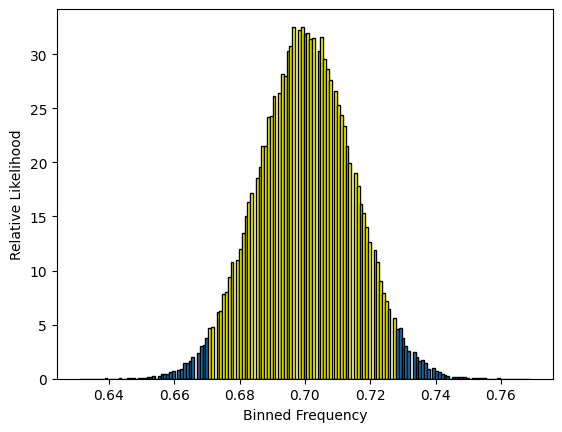

In [39]:
#Coloring histogram bars over an interval
likelihoods, bin_edges, patches = plt.hist(frequency_array, bins='auto',
 edgecolor='black', density=True)
bin_width = bin_edges[1] - bin_edges[0]
start_index, end_index = compute_high_confidence_interval(likelihoods,
 bin_width)
for i in range(start_index, end_index):
 patches[i].set_facecolor('yellow')
plt.xlabel('Binned Frequency')
plt.ylabel('Relative Likelihood')
plt.show()

The frequency range 0.695769 - 0.703708 represents a 95.06% confidence interval


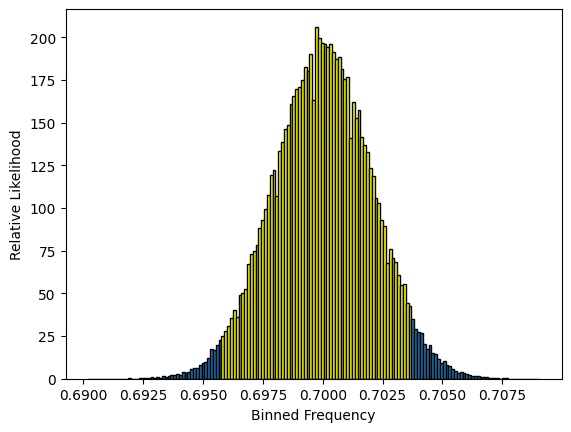

In [40]:
#Sampling 5 billion flipped coins
np.random.seed(0)
head_count_array = np.random.binomial(50000, 0.7, 100000)
frequency_array = head_count_array / 50000
likelihoods, bin_edges, patches = plt.hist(frequency_array, bins='auto',
 edgecolor='black', density=True)
bin_width = bin_edges[1] - bin_edges[0]
start_index, end_index = compute_high_confidence_interval(likelihoods,
 bin_width)
for i in range(start_index, end_index):
 patches[i].set_facecolor('yellow')
plt.xlabel('Binned Frequency')
plt.ylabel('Relative Likelihood')
plt.show()

In [41]:
#Computing a histogram using np.histogram
np.random.seed(0)
likelihoods, bin_edges = np.histogram(frequency_array, bins='auto',
 density=True)
bin_width = bin_edges[1] - bin_edges[0]
compute_high_confidence_interval(likelihoods, bin_width)

The frequency range 0.695769 - 0.703708 represents a 95.06% confidence interval


(np.int64(47), np.int64(114))

In [42]:
#Generating a random red card count
np.random.seed(0)
total_cards = 52
red_card_count = np.random.randint(0, total_cards + 1)

In [43]:
#Generating a black card count
black_card_count = total_cards - red_card_count
assert black_card_count != red_card_count

In [55]:
#Computing card probabilities using a sample space
def get_matching_event(event_condition, sample_space):
  return set([outcome for outcome in sample_space if event_condition(outcome)])
def compute_event_probability(event_condition, generic_sample_space):
 event = get_matching_event(event_condition, generic_sample_space)
 if type(generic_sample_space) == type(set()):
  return len(event) / len(generic_sample_space)
 event_size = sum(generic_sample_space[outcome] for outcome in event)
 return event_size / sum(generic_sample_space.values())
weighted_sample_space = {'red_card': red_card_count,
 'black_card': black_card_count}
prob_red = compute_event_probability(lambda x: x == 'red_card', weighted_sample_space)

In [56]:
#Computing card probabilities using division
assert prob_red == red_card_count / total_cards

In [57]:
#Simulating a random card
np.random.seed(0)
color = 'red' if np.random.binomial(1, prob_red) else 'black'
print(f"The first card in the shuffled deck is {color}")

The first card in the shuffled deck is red


In [58]:
#Simulating 10 random cards
np.random.seed(0)
red_count = np.random.binomial(10, prob_red)
print(f"In {red_count} of out 10 shuffles, a red card came up first.")

In 8 of out 10 shuffles, a red card came up first.


In [59]:
#Computing card probability confidence intervals
np.random.seed(0)
red_card_count_array = np.random.binomial(50000, prob_red, 100000)
frequency_array = red_card_count_array / 50000
likelihoods, bin_edges = np.histogram(frequency_array, bins='auto',
 density=True)
bin_width = bin_edges[1] - bin_edges[0]
start_index, end_index = compute_high_confidence_interval(likelihoods, bin_width)

The frequency range 0.842865 - 0.849139 represents a 95.16% confidence interval


In [61]:
#Estimating the red card count
range_start = round(0.842771 * total_cards)
range_end = round(0.849139 * total_cards)
print(f"The number of red cards in the deck is between {range_start} and {range_end}")


The number of red cards in the deck is between 44 and 44


In [62]:
#Validating the red card count
if red_card_count == 44:
 print('We are correct! There are 44 red cards in the deck')
else:
 print('Oops! Our sampling estimation was wrong.')

We are correct! There are 44 red cards in the deck


In [63]:
#Shuffling a four-card deck
np.random.seed(0)
card_deck = [1, 1, 0, 0]
np.random.shuffle(card_deck)
print(card_deck)

[0, 0, 1, 1]


In [64]:
#Returning a copy of the shuffled deck
np.random.seed(0)
unshuffled_deck = [1, 1, 0, 0]
shuffled_deck = np.random.permutation(unshuffled_deck)
assert unshuffled_deck == [1, 1, 0, 0]
print(shuffled_deck)

[0 0 1 1]


In [65]:
#Iterating over card permutations
import itertools
for permutation in list(itertools.permutations(unshuffled_deck))[:3]:
 print(permutation)

(1, 1, 0, 0)
(1, 1, 0, 0)
(1, 0, 1, 0)


In [66]:
#Monitoring permutation swaps
for permutation in list(itertools.permutations([0, 1, 2, 3]))[:3]:
 print(permutation)

(0, 1, 2, 3)
(0, 1, 3, 2)
(0, 2, 1, 3)


In [67]:
#Computing permutation counts
weighted_sample_space = defaultdict(int)
for permutation in itertools.permutations(unshuffled_deck):
 weighted_sample_space[permutation] += 1
for permutation, count in weighted_sample_space.items():
 print(f"Permutation {permutation} occurs {count} times")


Permutation (1, 1, 0, 0) occurs 4 times
Permutation (1, 0, 1, 0) occurs 4 times
Permutation (1, 0, 0, 1) occurs 4 times
Permutation (0, 1, 1, 0) occurs 4 times
Permutation (0, 1, 0, 1) occurs 4 times
Permutation (0, 0, 1, 1) occurs 4 times


In [68]:
#Computing permutation probabilities
sample_space = set(itertools.permutations(unshuffled_deck))
event_condition = lambda x: list(x) == unshuffled_deck
prob = compute_event_probability(event_condition, sample_space)
assert prob == 1 / len(sample_space)
print(f"Probability that a shuffle does not alter the deck is {prob}")

Probability that a shuffle does not alter the deck is 0.16666666666666666


In [69]:
#Computing a 10-card sample space
red_cards = 5 * [1]
black_cards = 5 * [0]
unshuffled_deck = red_cards + black_cards
sample_space = set(itertools.permutations(unshuffled_deck))
print(f"Sample space for a 10-card deck contains {len(sample_space)} elements")

Sample space for a 10-card deck contains 252 elements


# **Summary**

By using the np.random.binomial method, we can simulate random coin flips.

After many repeated coin flips, the frequency of heads converges closer to the true probability of heads.

By plotting a histogram (graph that shows the frequencies of numeric values), we can see the variability of the frequencies. By transforming the histogram into relative likelihoods, you get a probability distribution in which the area under the graph sums to 1. The area around the peak of the distribution is a confidence interval, which is a range of values that have a likelihood of an unknown probability falling between them.

When there are many sampled frequencies,  the histogram starts to resemble a normal distribution (bell-shaped curve).

You can simulate card shuffles using the np.random.permutation method. By using itertools.permutations, you can go through every possible permutation in a deck. This is too large for a normal sized deck, but can be done for smaller decks, such as 10 cards.